# 06 — Entrenamiento de Diffusion Policy para Bin Picking

**TFM: Pose 6-DoF con Transformers y Difusión**

Este notebook entrena el modelo de Diffusion Policy con datos sintéticos
de demostraciones de agarre generadas heurísticamente.

Fases:
1. Generar datos de entrenamiento (trayectorias heurísticas con variación)
2. Entrenar ConditionalUNet1D con DDPM loss
3. Evaluar: comparar trayectorias generadas vs heurísticas
4. Exportar pesos para uso en pipeline local

⚠️ **Ejecutar en Google Colab con GPU T4**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Giocrisrai/pose6dof-transformers-diffusion/blob/main/notebooks/06_diffusion_policy_training.ipynb)

In [1]:
# LOCAL execution (M1 Pro MPS) - adaptado desde Colab
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
import torch
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'Device: {device} | torch: {torch.__version__}')
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
print('CWD:', Path.cwd())


Device: mps | torch: 2.11.0
CWD: /Users/giocrisraigodoy/Documents/MATLAB/TFM/repo_tfm


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sys
sys.path.insert(0, '.')

from src.utils.lie_groups import so3_exp, pose_from_Rt, so3_log
from src.planning.diffusion_policy import (
    SimpleDDPMScheduler, ConditionalUNet1D, DiffusionGraspPlanner
)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {device}')

Device: mps


## 1. Generar Dataset de Entrenamiento

Generamos trayectorias heurísticas con variaciones:
- Diferentes poses de objeto (posición + rotación)
- Variación en distancia de approach y altura de lift
- Ruido gaussiano leve para diversidad

In [3]:
def generate_training_data(n_samples=2000, horizon=16, action_dim=7, seed=42):
    """Generate diverse heuristic grasp trajectories."""
    np.random.seed(seed)
    planner = DiffusionGraspPlanner(action_dim=action_dim, horizon=horizon)
    
    trajectories = []
    conditions = []
    
    for i in range(n_samples):
        # Random object pose on table
        t_obj = np.array([
            np.random.uniform(0.1, 0.5),   # x
            np.random.uniform(-0.2, 0.2),  # y
            np.random.uniform(0.02, 0.08), # z (on table)
        ])
        omega = np.random.randn(3) * 0.3
        R_obj = so3_exp(omega)
        object_pose = pose_from_Rt(R_obj, t_obj)
        
        # Vary approach parameters
        approach = np.random.uniform(0.10, 0.20)
        lift = np.random.uniform(0.08, 0.15)
        
        traj = planner.plan_grasp_heuristic(object_pose, approach, lift)
        
        # Add slight noise for diversity
        noise = np.random.randn(*traj.shape) * 0.005
        noise[..., 6] = 0  # don't noise gripper
        traj = traj + noise
        
        # Condition: flattened pose (first 12 elements of 4x4, padded to 64)
        cond = np.zeros(64)
        cond[:12] = object_pose[:3, :].flatten()
        
        trajectories.append(traj[0])  # remove batch dim
        conditions.append(cond)
    
    return np.array(trajectories), np.array(conditions)

trajs, conds = generate_training_data(n_samples=5000)
print(f'Trajectories: {trajs.shape}')  # (5000, 16, 7)
print(f'Conditions: {conds.shape}')     # (5000, 64)

Trajectories: (5000, 16, 7)
Conditions: (5000, 64)


In [4]:
class GraspDataset(Dataset):
    def __init__(self, trajectories, conditions):
        self.trajectories = torch.tensor(trajectories, dtype=torch.float32)
        self.conditions = torch.tensor(conditions, dtype=torch.float32)
    
    def __len__(self):
        return len(self.trajectories)
    
    def __getitem__(self, idx):
        return self.trajectories[idx], self.conditions[idx]

# Split
n_train = int(0.9 * len(trajs))
train_ds = GraspDataset(trajs[:n_train], conds[:n_train])
val_ds = GraspDataset(trajs[n_train:], conds[n_train:])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

print(f'Train: {len(train_ds)}, Val: {len(val_ds)}')

Train: 4500, Val: 500


## 2. Entrenamiento DDPM

In [5]:
# Model and scheduler
model = ConditionalUNet1D(
    action_dim=7,
    horizon=16,
    cond_dim=64,
    hidden_dim=128,
).to(device)

scheduler = SimpleDDPMScheduler(num_timesteps=100)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-6)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# Convert scheduler arrays to tensors
alpha_bar = torch.tensor(scheduler.alpha_bar, dtype=torch.float32, device=device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}')

Model parameters: 345,991


In [6]:
# Training loop
n_epochs = 30  # local MPS quick run
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    # Train
    model.train()
    epoch_loss = 0
    n_batches = 0
    
    for batch_trajs, batch_conds in train_loader:
        batch_trajs = batch_trajs.to(device)
        batch_conds = batch_conds.to(device)
        B = batch_trajs.shape[0]
        
        # Sample random timesteps
        t = torch.randint(0, scheduler.num_timesteps, (B,), device=device)
        
        # Add noise (forward process)
        eps = torch.randn_like(batch_trajs)
        ab = alpha_bar[t].view(B, 1, 1)
        x_t = torch.sqrt(ab) * batch_trajs + torch.sqrt(1 - ab) * eps
        
        # Predict noise
        eps_pred = model(x_t, t, batch_conds)
        
        # MSE loss
        loss = F.mse_loss(eps_pred, eps)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    lr_scheduler.step()
    train_loss = epoch_loss / n_batches
    train_losses.append(train_loss)
    
    # Validate
    model.eval()
    val_loss = 0
    n_val = 0
    with torch.no_grad():
        for batch_trajs, batch_conds in val_loader:
            batch_trajs = batch_trajs.to(device)
            batch_conds = batch_conds.to(device)
            B = batch_trajs.shape[0]
            
            t = torch.randint(0, scheduler.num_timesteps, (B,), device=device)
            eps = torch.randn_like(batch_trajs)
            ab = alpha_bar[t].view(B, 1, 1)
            x_t = torch.sqrt(ab) * batch_trajs + torch.sqrt(1 - ab) * eps
            eps_pred = model(x_t, t, batch_conds)
            val_loss += F.mse_loss(eps_pred, eps).item()
            n_val += 1
    
    val_loss /= n_val
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{n_epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {lr_scheduler.get_last_lr()[0]:.6f}')

Epoch  10/30 | Train: 0.067041 | Val: 0.067333 | LR: 0.000098


Epoch  20/30 | Train: 0.046592 | Val: 0.046327 | LR: 0.000090


Epoch  30/30 | Train: 0.036432 | Val: 0.035260 | LR: 0.000079


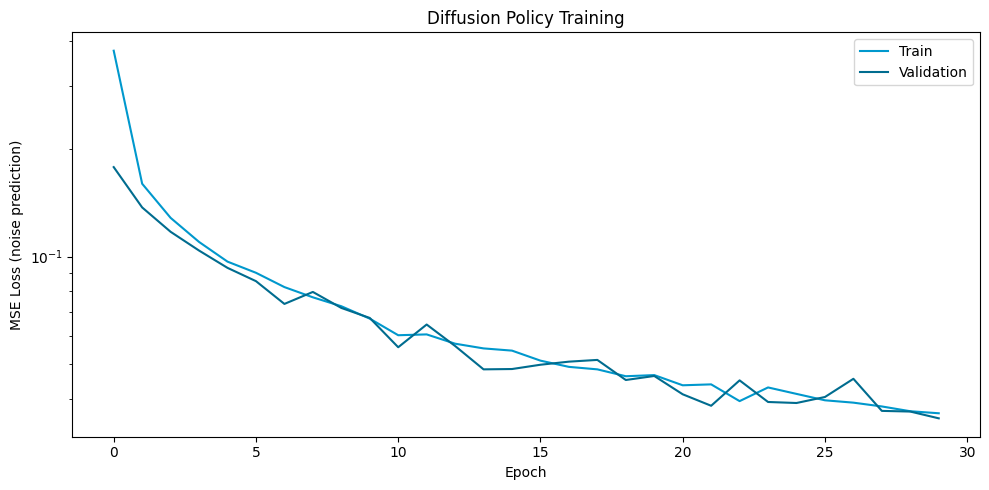

In [7]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Train', color='#0098CD')
ax.plot(val_losses, label='Validation', color='#006C8F')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (noise prediction)')
ax.set_title('Diffusion Policy Training')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('experiments/results/diffusion_training/training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Evaluación: Generar Trayectorias

In [8]:
@torch.no_grad()
def sample_trajectory(model, scheduler, cond, n_samples=1, device=device):
    """Generate trajectories via reverse diffusion."""
    model.eval()
    alpha_bar_t = torch.tensor(scheduler.alpha_bar, dtype=torch.float32, device=device)
    alphas_t = torch.tensor(scheduler.alphas, dtype=torch.float32, device=device)
    betas_t = torch.tensor(scheduler.betas, dtype=torch.float32, device=device)
    
    cond = cond.to(device)
    if cond.dim() == 1:
        cond = cond.unsqueeze(0).repeat(n_samples, 1)
    
    x = torch.randn(n_samples, 16, 7, device=device)
    
    for t in reversed(range(scheduler.num_timesteps)):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch, cond)
        
        ab = alpha_bar_t[t]
        a = alphas_t[t]
        b = betas_t[t]
        
        x_0_pred = (x - torch.sqrt(1 - ab) * eps_pred) / torch.sqrt(ab)
        
        if t > 0:
            ab_prev = alpha_bar_t[t-1]
            mu = (torch.sqrt(ab_prev) * b / (1 - ab)) * x_0_pred + \
                 (torch.sqrt(a) * (1 - ab_prev) / (1 - ab)) * x
            sigma = torch.sqrt(b * (1 - ab_prev) / (1 - ab))
            x = mu + sigma * torch.randn_like(x)
        else:
            x = x_0_pred
    
    return x.cpu().numpy()

# Generate samples with a test condition
test_cond = torch.tensor(conds[n_train], dtype=torch.float32)  # first val sample
gt_traj = trajs[n_train]  # ground truth

generated = sample_trajectory(model, scheduler, test_cond, n_samples=8, device=device)
print(f'Generated: {generated.shape}')

Generated: (8, 16, 7)


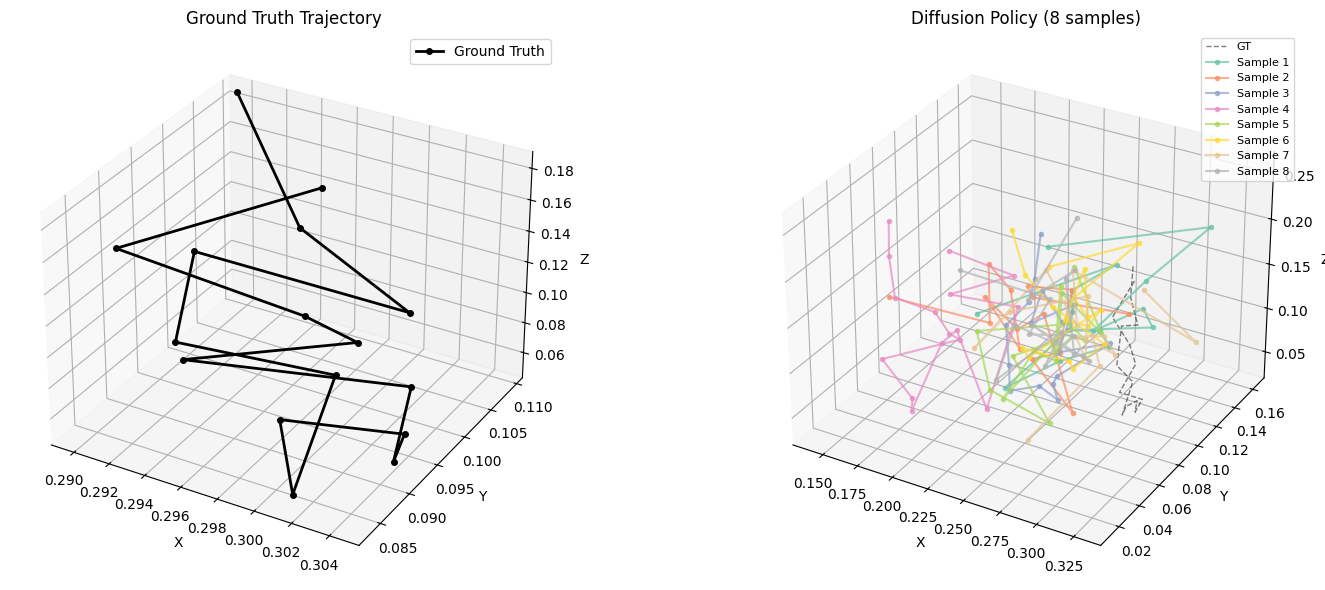

In [9]:
# Visualize: GT vs Generated
fig = plt.figure(figsize=(16, 6))

# GT
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot3D(gt_traj[:, 0], gt_traj[:, 1], gt_traj[:, 2], 'k-o', linewidth=2, markersize=4,
           label='Ground Truth')
ax1.set_title('Ground Truth Trajectory')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.legend()

# Generated (multimodal)
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot3D(gt_traj[:, 0], gt_traj[:, 1], gt_traj[:, 2], 'k--', linewidth=1, alpha=0.5,
           label='GT')
colors = plt.cm.Set2(np.linspace(0, 1, len(generated)))
for i, traj in enumerate(generated):
    ax2.plot3D(traj[:, 0], traj[:, 1], traj[:, 2], '-o', color=colors[i],
              linewidth=1.5, markersize=3, alpha=0.7, label=f'Sample {i+1}')
ax2.set_title(f'Diffusion Policy ({len(generated)} samples)')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('experiments/results/diffusion_training/generated_vs_gt.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Quantitative: MSE between generated and GT
n_eval = 100
mse_scores = []

for i in range(n_eval):
    idx = n_train + i
    cond_i = torch.tensor(conds[idx], dtype=torch.float32)
    gt_i = trajs[idx]
    
    gen_i = sample_trajectory(model, scheduler, cond_i, n_samples=1, device=device)
    mse = np.mean((gen_i[0] - gt_i) ** 2)
    mse_scores.append(mse)

print(f'Trajectory MSE over {n_eval} samples:')
print(f'  Mean: {np.mean(mse_scores):.6f}')
print(f'  Std:  {np.std(mse_scores):.6f}')
print(f'  Med:  {np.median(mse_scores):.6f}')

Trajectory MSE over 100 samples:
  Mean: 0.019995
  Std:  0.026760
  Med:  0.004982


## 4. Guardar Pesos

In [11]:
import os
os.makedirs('data/models', exist_ok=True)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'config': {
        'action_dim': 7,
        'horizon': 16,
        'cond_dim': 64,
        'hidden_dim': 128,
        'n_timesteps': 100,
        'n_epochs': n_epochs,
    }
}
torch.save(checkpoint, 'data/models/diffusion_policy_grasp.pth')
print('Saved: data/models/diffusion_policy_grasp.pth')
print(f'Size: {os.path.getsize("data/models/diffusion_policy_grasp.pth") / 1024 / 1024:.1f} MB')

Saved: data/models/diffusion_policy_grasp.pth
Size: 4.0 MB


In [12]:
# Saved weights are in weights/diffusion_policy.pth (local execution)
import os
if os.path.exists('weights/diffusion_policy.pth'):
    print('weights/diffusion_policy.pth =', os.path.getsize('weights/diffusion_policy.pth')/1024, 'KB')


---
**Autores:** Giocrisrai Godoy · José Miguel Carrasco | UNIR 2026